<a href="https://colab.research.google.com/github/DARIOYBETY123/Modulo-4-Deep-Leraning/blob/main/2_4_3_Loss_function_III.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
Clasificación Multiclase con Red Neuronal

Construye una red neuronal poco profunda para clasificación en 3 clases, usando la función de activación ReLU en la capa oculta y la función Softmax en la salida para convertir puntuaciones arbitrarias en probabilidades (no negativas, que suman 1).

In [10]:
!pip install pandas

In [11]:
# Cargar con un nombre más corto (alias)
import pandas as pd

import numpy as np
import matplotlib.pyplot as plt

Función de Activación ReLU

In [12]:
def ReLU(preactivation):
    activation = preactivation.clip(0.0)
    return activation

In [13]:
# Creamos valores de prueba (positivos, negativos y cero)
entrada = np.array([-2.5, -1.0, 0.0, 1.5, 3.0, -0.7])

# Llamamos a la función
salida = ReLU(entrada)

# Mostramos resultados
print("Entrada: ", entrada)
print("Salida ReLU:", salida)

Entrada:  [-2.5 -1.   0.   1.5  3.  -0.7]
Salida ReLU: [0.  0.  0.  1.5 3.  0. ]


Arquitectura de la Red



In [20]:
def shallow_nn(x, beta_0, omega_0, beta_1, omega_1):
    # Capa oculta: 3 unidades
    h1 = ReLU(beta_0 + omega_0 * x)
    # Capa de salida: 3 valores (uno por clase)
    model_out = beta_1 + omega_1 * h1
    return model_out


beta_0	(3,1)	Sesgos de capa oculta

omega_0	(3,1)	Pesos entrada → oculta

beta_1	(3,1)	Sesgos de capa de salida

omega_1	(3,3)	Pesos oculta → salida

Total de parámetros: 3 + 3 + 3 + 9 = 16 parámetros

Función Softmax

In [21]:
def softmax(model_out):
    exp_model_out = np.exp(model_out)
    sum_exp_model_out = np.sum(exp_model_out, axis=0, keepdims=True)
    softmax_model_out = exp_model_out / sum_exp_model_out
    return softmax_model_out

Parámetros Iniciales Predefinidos

Se proveen valores que aproximan bien los datos de entrenamiento. La red tiene 3 unidades ocultas y 3 salidas.


Visualización

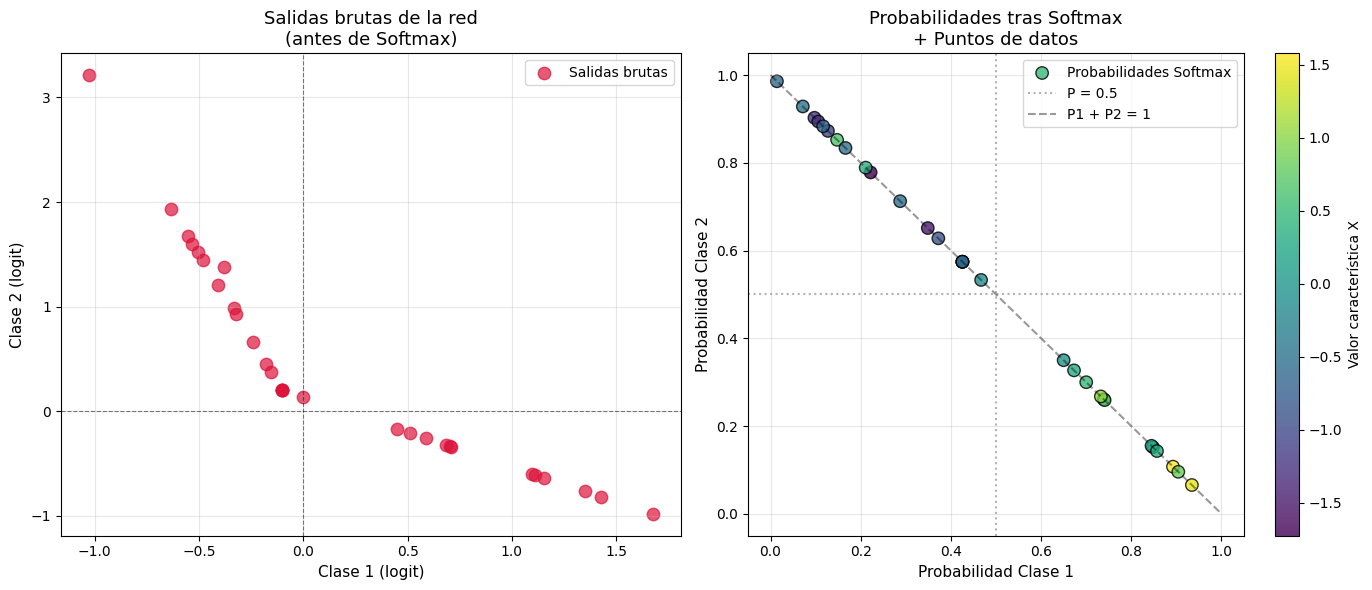

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------
# 1. Definir funciones
# ----------------------
def ReLU(preactivation):
    return preactivation.clip(0.0)

def softmax(z):
    # Estabilización numérica
    z = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

# ----------------------
# 2. Generar datos de ejemplo
# ----------------------
np.random.seed(42)  # Para reproducibilidad

# Puntos de datos (2 características para clasificación en 2D)
n_puntos = 30
X = np.random.randn(n_puntos, 2)  # Coordenadas (x1, x2)

# Simular salidas brutas de la red (antes de Softmax → 2 clases)
# Pesos y sesgos aleatorios para simular una red simple
w = np.array([[1.2, -0.8], [-0.5, 1.1]])
b = np.array([0.1, -0.2])

# Capa oculta con ReLU
z1 = X @ w + b
a1 = ReLU(z1)

# Salida bruta (logits) antes de Softmax
w2 = np.array([[0.9, -0.6], [-0.4, 1.3]])
b2 = np.array([-0.1, 0.2])
logits = a1 @ w2 + b2  # ← SALIDAS BRUTAS

# Probabilidades tras Softmax
probabilidades = softmax(logits)

# ----------------------
# 3. Crear gráfica con dos paneles
# ----------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- PANEL IZQUIERDO: Salidas brutas (logits) ---
ax1.scatter(logits[:, 0], logits[:, 1], c='crimson', s=80, alpha=0.7, label='Salidas brutas')
ax1.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax1.axvline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax1.set_title('Salidas brutas de la red\n(antes de Softmax)', fontsize=13)
ax1.set_xlabel('Clase 1 (logit)', fontsize=11)
ax1.set_ylabel('Clase 2 (logit)', fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.legend()

# --- PANEL DERECHO: Probabilidades Softmax + datos originales ---
sc = ax2.scatter(probabilidades[:, 0], probabilidades[:, 1],
                 c=X[:,0], cmap='viridis', s=80, alpha=0.8,
                 edgecolors='black', label='Probabilidades Softmax')

# Límites de probabilidad
ax2.axhline(0.5, color='gray', linestyle=':', alpha=0.6, label='P = 0.5')
ax2.axvline(0.5, color='gray', linestyle=':', alpha=0.6)
ax2.plot([0, 1], [1, 0], 'k--', alpha=0.4, label='P1 + P2 = 1')

ax2.set_title('Probabilidades tras Softmax\n+ Puntos de datos', fontsize=13)
ax2.set_xlabel('Probabilidad Clase 1', fontsize=11)
ax2.set_ylabel('Probabilidad Clase 2', fontsize=11)
ax2.set_xlim(-0.05, 1.05)
ax2.set_ylim(-0.05, 1.05)
ax2.grid(True, alpha=0.3)
ax2.legend()
plt.colorbar(sc, ax=ax2, label='Valor característica X')

plt.tight_layout()
plt.show()

Lógica de Ajuste

Se compara máxima verosimilitud vs mínima log-verosimilitud negativa (NLL) → coinciden en el mismo valor óptimo.

La verosimilitud es muy pequeña salvo parámetros casi correctos → en la práctica se minimiza la NLL.

El objetivo completo: ajustar los 16 parámetros hasta maximizar verosimilitud / minimizar NLL.